### Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(
    '../dataset/Dataset.xlsx',
    sheet_name='Sheet1'
)

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
df.shape

(1200, 14)

In [6]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

In [7]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [8]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [9]:
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

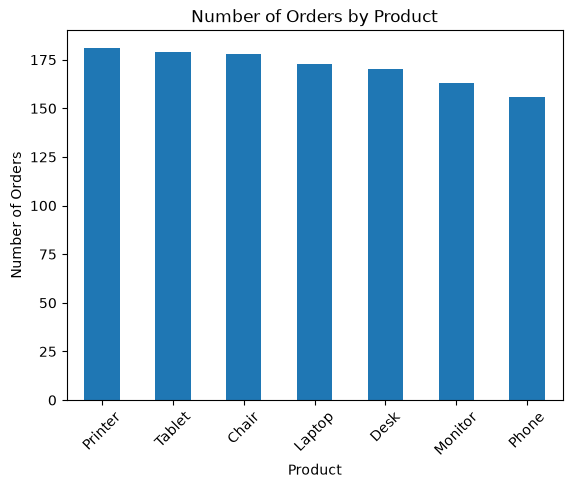

In [10]:
df['Product'].value_counts().plot(
    kind='bar',
    title='Number of Orders by Product'
)

plt.xlabel('Product')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

In [11]:
product_revenue = (
    df.groupby('Product')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

product_revenue

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

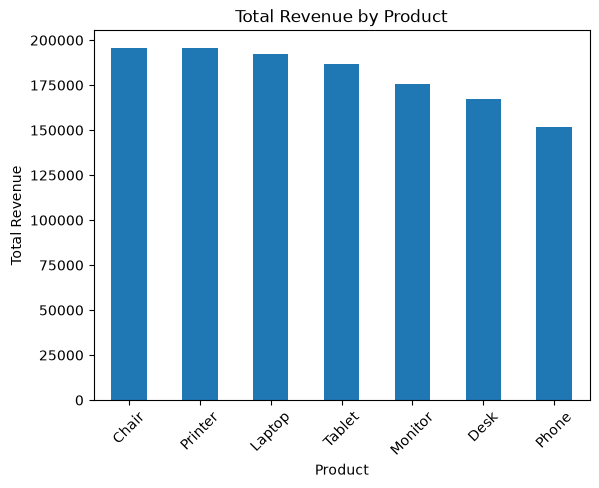

In [12]:
product_revenue.plot(
    kind='bar',
    title='Total Revenue by Product'
)

plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()

In [13]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

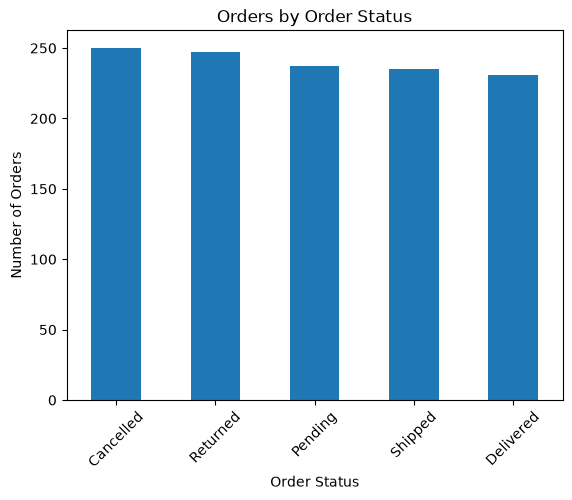

In [14]:
df['OrderStatus'].value_counts().plot(
    kind='bar',
    title='Orders by Order Status'
)

plt.xlabel('Order Status')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.show()

In [15]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [16]:
payment_revenue = (
    df.groupby('PaymentMethod')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

PaymentMethod
Credit Card    263847.63
Online         262442.94
Cash           259786.29
Gift Card      246323.92
Debit Card     232361.18
Name: TotalPrice, dtype: float64

In [17]:
df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [18]:
referral_revenue = (
    df.groupby('ReferralSource')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)

referral_revenue

ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

In [19]:
df['CouponCode'].value_counts()

CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [20]:
coupon_revenue = (
    df.groupby('CouponCode')['TotalPrice']
    .agg(['count', 'sum', 'mean'])
    .sort_values('sum', ascending=False)
)

coupon_revenue

,count,sum,mean
CouponCode,,,
FREESHIP,313,335036.99,1070.405719
SAVE10,286,304840.02,1065.874196
WINTER15,292,302483.54,1035.902534


In [21]:
monthly_sales = (
    df.set_index('Date')
    .resample('ME')['TotalPrice']
    .sum()
)

monthly_sales

Date
2023-01-31    56685.75
2023-02-28    40117.66
2023-03-31    48609.37
2023-04-30    27751.71
2023-05-31    63836.84
2023-06-30    49500.19
2023-07-31    42820.66
2023-08-31    54352.14
2023-09-30    29526.67
2023-10-31    52607.85
2023-11-30    43079.67
2023-12-31    43754.73
2024-01-31    38528.08
2024-02-29    36909.57
2024-03-31    36030.90
2024-04-30    49613.14
2024-05-31    27909.11
2024-06-30    68068.54
2024-07-31    42963.98
2024-08-31    31991.07
2024-09-30    39794.98
2024-10-31    37226.97
2024-11-30    32413.76
2024-12-31    38785.77
2025-01-31    29099.40
2025-02-28    35317.55
2025-03-31    39200.66
2025-04-30    31821.20
2025-05-31    43396.64
2025-06-30    53047.40
Freq: ME, Name: TotalPrice, dtype: float64

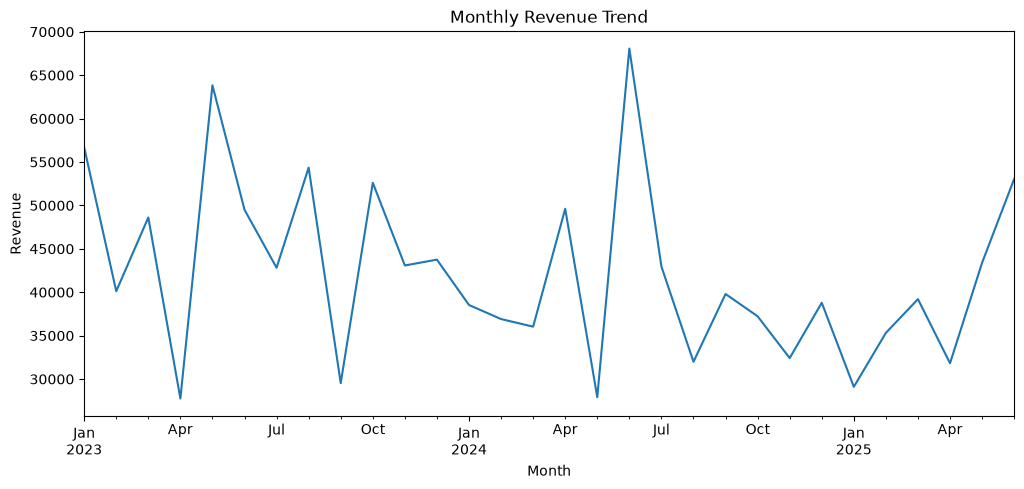

In [22]:
monthly_sales.plot(
    kind='line',
    title='Monthly Revenue Trend',
    figsize=(12, 5)
)

plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

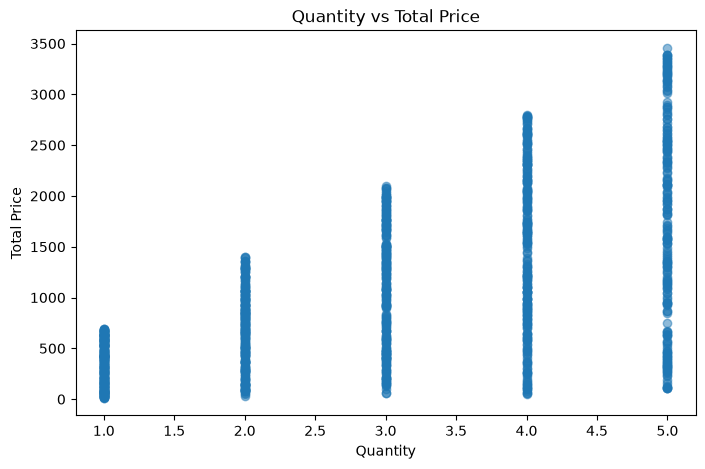

In [23]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Quantity'],
    df['TotalPrice'],
    alpha=0.5
)

plt.xlabel('Quantity')
plt.ylabel('Total Price')
plt.title('Quantity vs Total Price')

plt.show()

In [24]:
df['Quantity'].corr(df['TotalPrice'])

np.float64(0.6152513633467076)